# Aisle Diversity and User Reorder Rate

The customer segmentation team wants to determine whether users who shop from a wider variety of aisles have higher reorder rates.

## Load and prepare the data

Load the prior order, purchase, and product data and connect each purchase to its user and aisle.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr


DATA_DIR = "../../data/shop"

orders = pd.read_csv(
    f"{DATA_DIR}/orders.csv",
    usecols=["order_id", "user_id", "eval_set"],
)

order_products = pd.read_csv(
    f"{DATA_DIR}/order_products__prior.csv",
    usecols=["order_id", "product_id", "reordered"],
)

products = pd.read_csv(
    f"{DATA_DIR}/products.csv",
    usecols=["product_id", "aisle_id"],
)

prior_orders = orders[
    orders["eval_set"].eq("prior")
][["order_id", "user_id"]]

purchases = (
    order_products
    .merge(prior_orders, on="order_id")
    .merge(products, on="product_id")
)

purchases.head()

,order_id,product_id,reordered,user_id,aisle_id
0,2,33120,1,202279,86
1,2,28985,1,202279,83
2,2,9327,0,202279,104
3,2,45918,1,202279,19
4,2,30035,0,202279,17


## Calculate user-level shopping measures

For each user, calculate unique aisle count as a measure of shopping breadth and overall reorder rate as the mean of the item-level `reordered` indicator.

In [2]:
user_metrics = (
    purchases
    .groupby("user_id")
    .agg(
        unique_aisles=("aisle_id", "nunique"),
        reorder_rate=("reordered", "mean"),
        prior_orders=("order_id", "nunique"),
    )
    .reset_index()
)

print(
    user_metrics.head()
)

   user_id  unique_aisles  reorder_rate  prior_orders
0        1             12      0.694915            10
1        2             33      0.476923            14
2        3             16      0.625000            12
3        4             14      0.055556             5
4        5             16      0.378378             4


## Calculate the overall correlation

Measure the Pearson correlation between each user's unique aisle count and overall reorder rate.

In [3]:
corr, p_value = pearsonr(
    user_metrics["unique_aisles"],
    user_metrics["reorder_rate"],
)

print(
    "Correlation:",
    f"{corr:.3f}",
)

print(
    "P-value:",
    f"{p_value:.3g}",
)

Correlation: 0.314
P-value: 0


## Visualize aisle diversity and reorder behavior

Plot users' aisle diversity against reorder rate. Point size represents the number of prior orders in each user's shopping history.

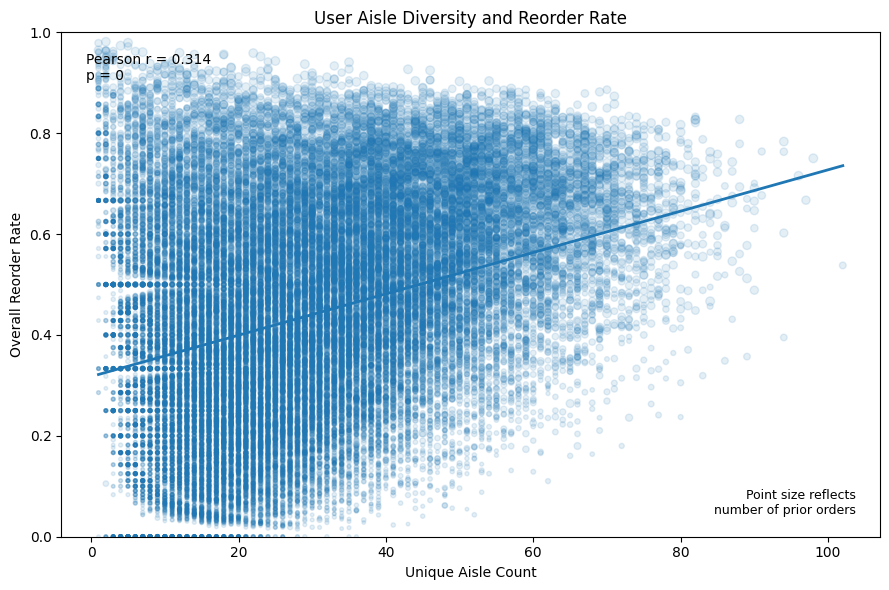

In [4]:
plot_data = user_metrics.sample(
    n=min(50_000, len(user_metrics)),
    random_state=42,
)

x = plot_data["unique_aisles"]
y = plot_data["reorder_rate"]

slope, intercept = np.polyfit(
    x,
    y,
    1,
)

x_line = np.linspace(
    x.min(),
    x.max(),
    200,
)

# Point size represents user activity.
point_sizes = (
    np.sqrt(plot_data["prior_orders"])
    * 4
)


fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.scatter(
    x,
    y,
    s=point_sizes,
    alpha=0.12,
)

ax.plot(
    x_line,
    slope * x_line + intercept,
    linewidth=2,
)

ax.set_title(
    "User Aisle Diversity and Reorder Rate"
)

ax.set_xlabel(
    "Unique Aisle Count"
)

ax.set_ylabel(
    "Overall Reorder Rate"
)

ax.set_ylim(
    0,
    1,
)

ax.text(
    0.03,
    0.96,
    (
        f"Pearson r = {corr:.3f}\n"
        f"p = {p_value:.3g}"
    ),
    transform=ax.transAxes,
    va="top",
)

ax.text(
    0.97,
    0.04,
    (
        "Point size reflects\n"
        "number of prior orders"
    ),
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
)

plt.tight_layout()
plt.show()

## Conclusion

The user-level analysis shows a moderate positive correlation between unique aisle count and overall reorder rate (**r = 0.314**).

This suggests that users who shop from a wider variety of aisles tend to have higher reorder rates on average.

The result indicates that aisle diversity may be useful as a behavioral signal for customer segmentation and personalized promotions.